Install chronos:

pip install chronos-forecasting


In [ ]:
import pandas as pd
import seaborn as sns
sns.set_theme(palette="colorblind")

from skforecast.foundation import FoundationModel, ForecasterFoundation
from skforecast.model_selection import TimeSeriesFold, backtesting_foundation
from sklearn.metrics import root_mean_squared_error

# Load data

In [19]:
url = "https://raw.githubusercontent.com/skforecast/skforecast-datasets/main/data/simulated_items_sales.csv"
df = pd.read_csv(url, parse_dates=["date"], index_col="date")
df.index.freq = 'D'

# set promotion for november each year
df['promotion'] = 0.0
df.loc['2012-11-01':'2012-11-30', 'promotion'] = 0.15
df.loc['2013-11-01':'2013-11-30', 'promotion'] = 0.2
df.loc['2014-11-01':'2014-11-30', 'promotion'] = 0.25

df.head()

,item_1,item_2,item_3,promotion
date,,,,
2012-01-01,8.253175,21.047727,19.429739,0.0
2012-01-02,22.777826,26.578125,28.009863,0.0
2012-01-03,27.549099,31.751042,32.078922,0.0
2012-01-04,25.895533,24.567708,27.252276,0.0
2012-01-05,21.379238,18.191667,20.357737,0.0


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1097 entries, 2012-01-01 to 2015-01-01
Freq: D
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   item_1     1097 non-null   float64
 1   item_2     1097 non-null   float64
 2   item_3     1097 non-null   float64
 3   promotion  1097 non-null   float64
dtypes: float64(4)
memory usage: 75.1 KB


# Train-test split

In [21]:
# 80% for training
train_size = int(df.shape[0]*0.8)

# Set up TimeSeriesFold

In [22]:
cv = TimeSeriesFold(
         steps=24,
         initial_train_size=train_size,
         refit=False
     )

# Baseline

In [23]:
# last-value baseline
from skforecast.model_selection import backtesting_forecaster
from skforecast.recursive import ForecasterEquivalentDate


results_list = []

for col in df.columns:

    if not col.startswith('item'):
        continue

    last_value_forecaster = ForecasterEquivalentDate(offset=1, n_offsets=1)

    results, predictions_backtest = backtesting_forecaster(
        forecaster=last_value_forecaster,
        y=df[col],
        cv=cv,
        metric=[root_mean_squared_error, 
                'mean_absolute_error'],
        n_jobs='auto',
        verbose=False,
        show_progress=True
    )
    results.index = [col]
    results_list.append(results)

baseline_results = pd.concat(results_list, axis=0)
baseline_results.loc["average"] = baseline_results.mean(axis=0)
baseline_results

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

,root_mean_squared_error,mean_absolute_error
item_1,2.379760,1.912030
item_2,3.512498,2.684428
item_3,4.928060,4.021367
average,3.606773,2.872609


# Model development and evaluation

In [6]:
estimator = FoundationModel(model_id="autogluon/chronos-2-small", context_length=365)
forecaster = ForecasterFoundation(estimator=estimator)

In [25]:
metrics_chronos, backtest_predictions = backtesting_foundation(
    forecaster=forecaster,
    series=df[['item_1', 'item_2', 'item_3']],
    levels=['item_1', 'item_2', 'item_3'], # or None
    exog=df[['promotion']],
    cv=cv,
    metric=[root_mean_squared_error, 'mean_absolute_error'],
    suppress_warnings=True
)

metrics_chronos

╭────────────────────────────────── InputTypeWarning ──────────────────────────────────╮
│ Passing a DataFrame (either wide or long format) as `series` requires additional     │
│ internal transformations, which can increase computational time. It is recommended   │
│ to use a dictionary of pandas Series instead. For more details, see:                 │
│ https://skforecast.org/latest/user_guides/independent-multi-time-series-forecasting. │
│ html#input-data                                                                      │
│                                                                                      │
│ Category : skforecast.exceptions.InputTypeWarning                                    │
│ Location :                                                                           │
│ c:\Users\pekarv\AppData\Local\anaconda3\Lib\site-packages\skforecast\utils\utils.py: │
│ 2799                                                                                 │
│ Suppress : warnings.simplefilter('ignore', category=InputTypeWarning)                │
╰──────────────────────────────────────────────────────────────────────────────────────╯

  0%|          | 0/10 [00:00<?, ?it/s]

,levels,root_mean_squared_error,mean_absolute_error
0,item_1,1.303979,0.864197
1,item_2,3.011753,2.287517
2,item_3,3.922458,3.093727
3,average,2.746063,2.081813
4,weighted_average,2.746063,2.081813
5,pooling,2.952778,2.081813


In [26]:
backtest_predictions.head()

,level,fold,pred
2014-05-27,item_1,0,23.131119
2014-05-27,item_2,0,16.057056
2014-05-27,item_3,0,17.850426
2014-05-28,item_1,0,23.227839
2014-05-28,item_2,0,15.755098


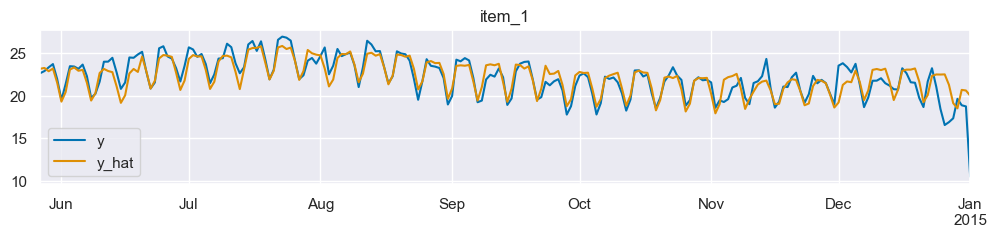

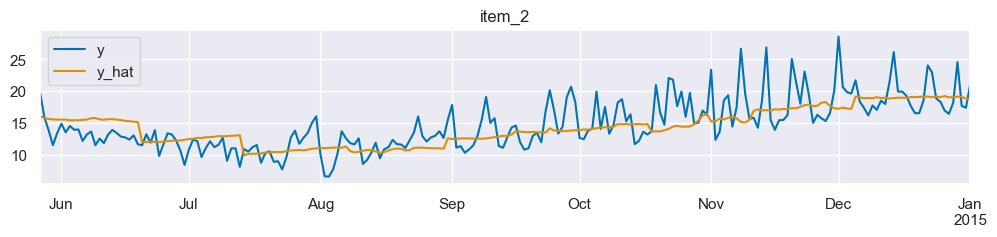

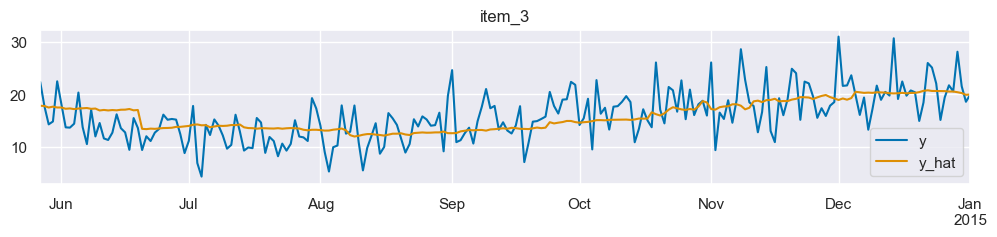

In [30]:
# for each item
for item in df.columns:
    if not item.startswith("item"):
        continue
    y_hat = backtest_predictions[backtest_predictions["level"] == item]['pred']
    tdf = pd.DataFrame({"y": df.loc[y_hat.index, item], "y_hat": y_hat})
    tdf.plot(figsize=(12,2), title=item)

# Citing this notebook

If you use this notebook in your work, please cite it as follows:
    
Pekar, V. (2026). Business Forecasting. Lecture examples and exercises. (Version 1.0.0). URL: https://github.com/vpekar/bf